# This is equivalent to Example C but contains only the code blocks as in the accompanying paper

In [1]:
# ruff: noqa
import os

os.sys.path.append("../../../..")

In [2]:
from feedback_grape.utils.states import basis, coherent
N_cav = 20
basis_state = basis(n=2)
coherent_state = coherent(n=N_cav, alpha=3)

In [3]:
from feedback_grape.utils.operators import create, destroy
number_operator = create(N_cav) @ destroy(N_cav)

In [4]:
from feedback_grape.utils.tensor import tensor
ground_qubit = basis(n=2)
ground_cavity = basis(n=N_cav)
ground_state = tensor(ground_cavity, ground_qubit)

In [5]:
import jax
import jax.numpy as jnp
from jax.scipy.linalg import expm
from feedback_grape.utils.operators import (
sigmap, sigmam, create, destroy, identity, cosm, sinm
)

In [6]:
def meas_operator(measurement_outcome, params):
    gamma, delta = params
    cav_operator = (
    gamma * create(N_cav) @ destroy(N_cav)
    + delta / 2 * identity(N_cav)
    )
    angle = tensor(cav_operator, identity(2))
    meas_op = jnp.where(
    measurement_outcome == 1,
    cosm(angle),
    sinm(angle),
    )
    return meas_op

In [7]:
def qubit_unitary(alphas):
    alpha_re, alpha_im = alphas
    alpha = alpha_re + 1j * alpha_im
    h_dt = (alpha*sigmap() + alpha.conjugate()*sigmam()) / 2
    return tensor(identity(N_cav), expm(-1j * h_dt))
    
def qubit_cavity_unitary(betas):
    beta_re, beta_im = betas
    beta = beta_re + 1j * beta_im
    a_sigp = tensor(destroy(N_cav), sigmap())
    adag_sigm = tensor(create(N_cav), sigmam())
    h_dt = (beta * a_sigp + beta.conjugate() * adag_sigm) / 2
    return expm(-1j * h_dt)

In [8]:
from feedback_grape.fgrape import Gate
key1, key2, key3 = jax.random.split(jax.random.PRNGKey(42), 3)
measure = Gate(
    gate=meas_operator,
    initial_params=jax.random.uniform(
        key1,
        shape=(2,),
        minval=-2 * jnp.pi,
        maxval=2 * jnp.pi,
    ),
    measurement_flag=True,
)
qub_unitary = Gate(
    gate=qubit_unitary,
    initial_params=jax.random.uniform(
        key2,
        shape=(2,),
        minval=-2 * jnp.pi,
        maxval=2 * jnp.pi,
    ),
    measurement_flag=False,
)
qub_cav = Gate(
    gate=qubit_cavity_unitary,
    initial_params=jax.random.uniform(
        key3,
        shape=(2,),
        minval=-2 * jnp.pi,
        maxval=2 * jnp.pi,
    ),
    measurement_flag=False,
)

In [9]:
n_average = 1
beta = jnp.log((1 / n_average) + 1)
diags = jnp.exp(-beta * jnp.arange(N_cav))
normalized_diags = diags / jnp.sum(diags, axis=0)
rho_cav0 = jnp.diag(normalized_diags)
rho_qub0 = basis(2, 0) @ basis(2, 0).conj().T
rho0 = tensor(rho_cav0, rho_qub0)

In [10]:
from feedback_grape.utils.states import fock
psi_cav_target = (
    fock(N_cav, 1) + fock(N_cav, 2) + fock(N_cav, 3)
) / jnp.sqrt(3)
psi_qub_target = basis(2, 0)
psi_target = tensor(psi_cav_target, psi_qub_target)
rho_target = psi_target @ psi_target.conj().T

In [11]:
system_params = [measure, qub_unitary, qub_cav]
num_time_steps = 5

In [12]:
from feedback_grape.fgrape import optimize_pulse
result = optimize_pulse(
    init_state=rho0,
    target_state=rho_target,
    system_params=system_params,
    num_time_steps=num_time_steps,
    mode="lookup",
    goal="fidelity",
    max_iter=1000,
    convergence_threshold=1e-6,
    learning_rate=0.02,
    evo_type="density",
    progress=True,
    batch_size=10,
    eval_time_steps=2*num_time_steps
)

Iteration 10, Loss: 0.619694, T=3s, eta=286s
Iteration 20, Loss: 0.559191, T=6s, eta=296s
Iteration 30, Loss: 0.654462, T=9s, eta=298s
Iteration 40, Loss: 0.690517, T=12s, eta=297s
Iteration 50, Loss: 0.606377, T=15s, eta=298s
Iteration 60, Loss: 0.688028, T=19s, eta=295s
Iteration 70, Loss: 0.736810, T=22s, eta=292s
Iteration 80, Loss: 0.865780, T=25s, eta=290s
Iteration 90, Loss: 0.895460, T=28s, eta=287s
Iteration 100, Loss: 1.038856, T=31s, eta=284s
Iteration 110, Loss: 1.158938, T=35s, eta=281s
Iteration 120, Loss: 1.002144, T=38s, eta=278s
Iteration 130, Loss: 0.755226, T=41s, eta=275s
Iteration 140, Loss: 0.877550, T=44s, eta=272s
Iteration 150, Loss: 1.289478, T=47s, eta=268s
Iteration 160, Loss: 0.713522, T=50s, eta=265s
Iteration 170, Loss: 1.031733, T=54s, eta=262s
Iteration 180, Loss: 1.096958, T=57s, eta=259s
Iteration 190, Loss: 1.128355, T=60s, eta=256s
Iteration 200, Loss: 0.994936, T=63s, eta=253s
Iteration 210, Loss: 1.328315, T=66s, eta=250s
Iteration 220, Loss: 1.22

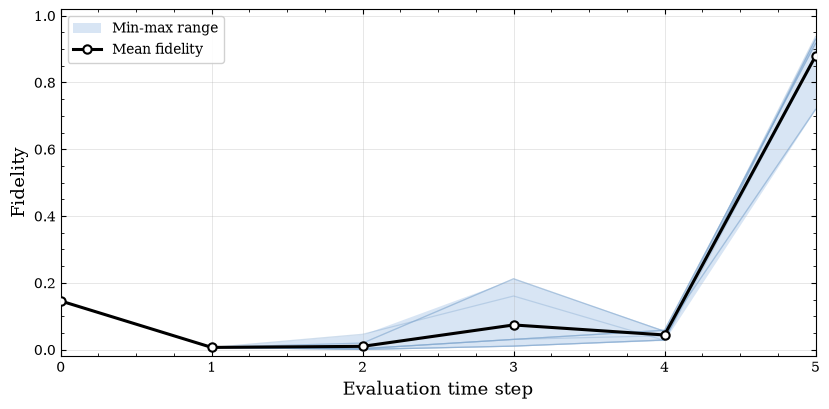

In [13]:
# Fidelity vs. evaluation time step.
# `result.fidelity_each_timestep` is a list of length eval_time_steps + 1
# (index 0 = initial state); each entry holds the fidelity of every
# evaluation trajectory in the batch at that time step.
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import matplotlib.pyplot as plt
n_steps = 5  # only plot the initial state plus the first `n_steps` time steps
fid = jnp.stack(result.fidelity_each_timestep)[: n_steps + 1]  # (n_steps + 1, batch)
t = jnp.arange(fid.shape[0])

fid_mean = fid.mean(axis=1)
fid_min = fid.min(axis=1)
fid_max = fid.max(axis=1)

peak_idx = int(jnp.argmax(fid_mean))
peak_val = float(fid_mean[peak_idx])

with plt.rc_context({
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.6,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
}):
    fig, ax = plt.subplots(figsize=(10, 4.2))

    # min-max envelope across the evaluation batch
    ax.fill_between(
        t, fid_min, fid_max,
        color="#a9c6e8", alpha=0.45, lw=0, label="Min-max range",
    )
    # individual trajectories, faint, inside the band
    ax.plot(t, fid, color="#7ba3cc", alpha=0.35, lw=0.9)
    # batch-mean fidelity
    ax.plot(
        t, fid_mean,
        color="black", lw=2.2, marker="o", ms=6,
        mfc="white", mec="black", mew=1.5, zorder=5,
        label="Mean fidelity",
    )

    ax.set_xlabel("Evaluation time step", fontsize=13)
    ax.set_ylabel("Fidelity", fontsize=13)
    ax.set_xlim(t[0], t[-1])
    ax.set_ylim(-0.02, 1.02)
    # numbered major ticks plus unnumbered minor ticks on both axes
    ax.set_xticks(t)
    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax.legend(loc="upper left", framealpha=0.9)
    # leave room on the right for the outside annotation
    fig.tight_layout(rect=(0, 0, 0.84, 1))
    plt.show()